In [ ]:
from pathlib import Path
import pickle
import numpy as np
import gvar as gv

import matplotlib.pyplot as plt
%matplotlib inline

from measurements import *
from flowing import flowtime_to_radius

In [ ]:
from ensemble_data import data_16_x_64_1p5Tc as ense_data

ns = ense_data['ns']
nt = ense_data['nt']

flowtimes = ense_data['flowtimes']

In [3]:
data_path = Path.cwd() / 'data'

skip_configs = 55

flowmeas_config : list[FlowMeasurements] = pickle.load((data_path / 'data0a.pkl').open('rb'))[skip_configs:]

ense_all = np.load(data_path / 'data0.npy')[skip_configs:]
print(ense_all.shape)

print('number of configs =', len(flowmeas_config))

(4000, 22, 9, 1914)
number of configs = 4000


In [4]:
# all improved topological charges (first index is config, second is flowtime)

n_configs   = len(flowmeas_config)
n_flowtimes = len(flowtimes)

icharge_config_flow = np.array(
    [ [meas.icharge for meas in flowmeas]
      for flowmeas in flowmeas_config ],
    dtype=float
)
print(icharge_config_flow.shape, icharge_config_flow.dtype)

(4000, 22) float64


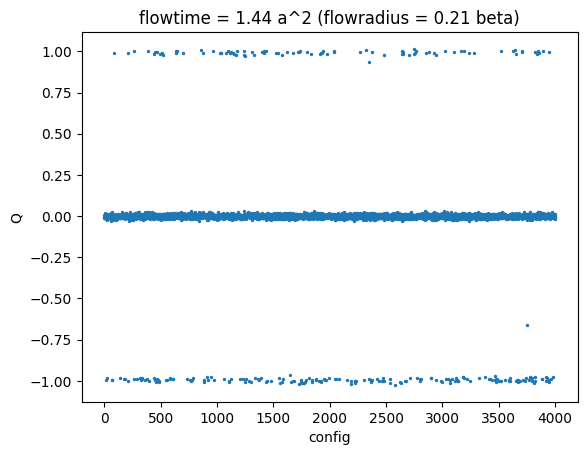

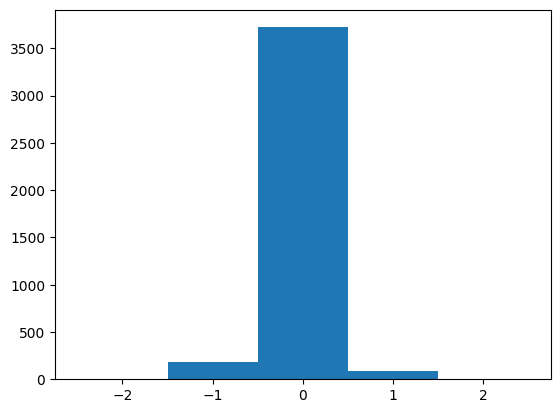

In [8]:
# plotting topological charge for each configuration

iflow = -1

plt.scatter(
    x = range(n_configs),
    y = icharge_config_flow[:, iflow],
    s = 2,
    # label = f't = {flowtimes[iflow]:.2f}'
)
plt.xlabel('config')
plt.ylabel('Q')
# plt.legend()
plt.title(f'flowtime = {flowtimes[iflow]:.2f} a^2 (flowradius = {flowtime_to_radius(flowtimes[iflow], nt):.2f} beta)')
plt.show()
plt.close()


plt.hist(
    x = icharge_config_flow[:, iflow],
    bins = (-2.5, -1.5, -0.5, 0.5, 1.5, 2.5)
)
plt.show()

[0.02572924 0.05303278 0.08103495 0.11020878 0.14105839 0.17368938
 0.20868351 0.24545494 0.28381172 0.32491525 0.37051014 0.41794493
 0.46962332 0.52795598 0.58909938 0.65702151 0.73468031 0.82577388
 0.9353328  1.06959077 1.23382028 1.43593646]


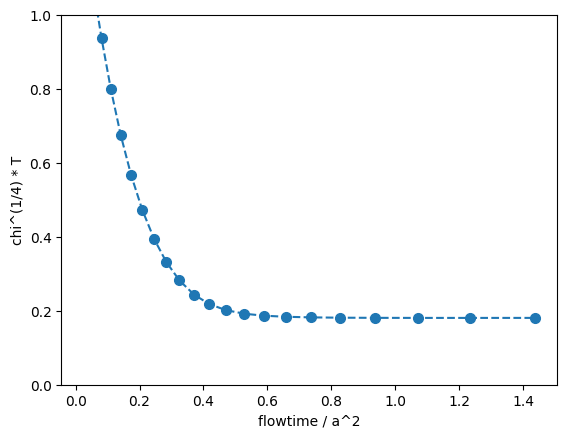

In [30]:
# topological susceptibility as function of flowtime

top_sus = np.mean(icharge_config_flow**2, axis=0) / (ns/nt)**3
top_sus_4 = top_sus ** (1/4)

plt.errorbar(
    x = flowtimes,
    y = top_sus_4,
    marker = 'o',
    markersize = 7,
    ls='--'
)
print(flowtimes)

plt.xlabel('flowtime / a^2')
plt.ylabel('chi^(1/4) * T')

plt.ylim(0, 1)

plt.show()

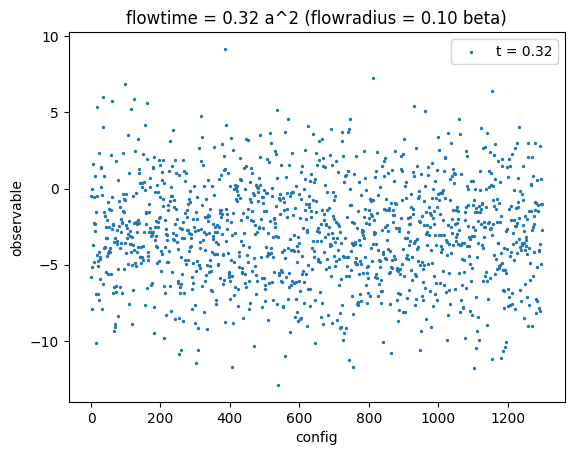

In [16]:
# thermalization

iflow = 9
config_max = 1300

obs = ense_all[:, iflow, 5, 2]

plt.scatter(
    x = range(config_max),
    y = obs[:config_max],
    s = 2,
    label = f't = {flowtimes[iflow]:.2f}'
)
plt.xlabel('config')
plt.ylabel('observable')
plt.legend()
plt.title(f'flowtime = {flowtimes[iflow]:.2f} a^2 (flowradius = {flowtime_to_radius(flowtimes[iflow], nt):.2f} beta)')
plt.show()

/tmp/ipykernel_423081/3837609552.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


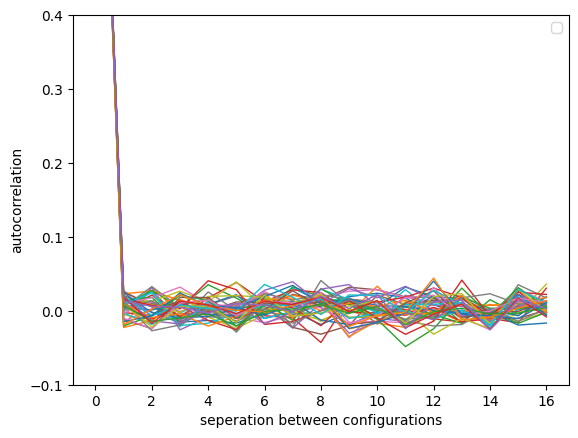

In [26]:
# check autocorrelation

skip = 55

taus   = [4,6,8]
iflows = [11, 16, 21]
irs    = [0, 5, 15, 30, 45]

for iflow in iflows:
    for tau in taus:
        for ir in irs:
            autocorrs = gv.dataset.autocorr(ense_all[skip:, iflow, tau, ir])
            plt.plot(
                autocorrs[:17],
                lw = 1,
                # label = f'ifl={ifl}'
            )
            plt.legend()

plt.ylim(-0.1, 0.4)
plt.xlabel('seperation between configurations')
plt.ylabel('autocorrelation')
# plt.title('autocorrelation of wide range of flowtimes, time and spatial separations')
plt.show()